# FIT5217 — Assignment 2: Task 1 — Sequence-to-Sequence Recipe Generation with RNNs

**Name:** [Kwok Chung Hang]  
**Student ID:** [35850043]  
**Task:** Task 1 — RNN Seq2Seq with and without Attention  

## Generative AI Usage Declaration

I used generative AI tools to assist with coding, understanding the assignment, and supporting the analysis.

### AI tools used
- ChatGPT (OpenAI): used for
  - Understanding assignment requirements
  - Debugging code and explaining implementation issues
  - Improving code structure and efficiency
  - Assisting with analysis and interpretation of results

In [2]:
!pip install -q nltk sacrebleu evaluate bert-score
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.0 MB/s eta 0:00:00
Dependencies installed.


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:

BASE      = '/content/drive/MyDrive/Cooking_Dataset'
DRIVE_DIR = BASE

In [5]:
!pip install -q sacrebleu bert_score
import gc, pickle, os, json, math, time, random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import matplotlib.pyplot as plt
import sacrebleu
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [6]:
TRAIN_PATH = f'{BASE}/train.csv'
DEV_PATH   = f'{BASE}/dev.csv'
TEST_PATH  = f'{BASE}/test.csv'

In [7]:
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df_val   = pd.read_csv(DEV_PATH)
df_train.head()

,Title,Ingredients,Recipe
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar..."
1,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C..."
2,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ..."
3,Cheeseburger Potato Soup,"[""6 baking potatoes"", ""1 lb. of extra lean gro...","[""Wash potatoes; prick several times with a fo..."
4,Rhubarb Coffee Cake,"[""1 1/2 c. sugar"", ""1/2 c. butter"", ""1 egg"", ""...","[""Cream sugar and butter."", ""Add egg and beat ..."


### Basic Exploratory Data Analysis (For understanding for the dataset)

In [8]:
print(df_train.isnull().sum())
print((df_train['Ingredients'] == 'nan').sum())
print((df_train['Recipe'] == 'nan').sum())

for i in range(3):
    print("ING:", df_train['Ingredients'].iloc[i])
    print("REC:", df_train['Recipe'].iloc[i])
    print("-----")

Title          0
Ingredients    0
Recipe         0
dtype: int64
0
0
ING: ["1 c. firmly packed brown sugar", "1/2 c. evaporated milk", "1/2 tsp. vanilla", "1/2 c. broken nuts (pecans)", "2 Tbsp. butter or margarine", "3 1/2 c. bite size shredded rice biscuits"]
REC: ["In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.", "Stir over medium heat until mixture bubbles all over top.", "Boil and stir 5 minutes more. Take off heat.", "Stir in vanilla and cereal; mix well.", "Using 2 teaspoons, drop and shape into 30 clusters on wax paper.", "Let stand until firm, about 30 minutes."]
-----
ING: ["2 (16 oz.) pkg. frozen corn", "1 (8 oz.) pkg. cream cheese, cubed", "1/3 c. butter, cubed", "1/2 tsp. garlic powder", "1/2 tsp. salt", "1/4 tsp. pepper"]
REC: ["In a slow cooker, combine all ingredients. Cover and cook on low for 4 hours or until heated through and cheese is melted. Stir well before serving. Yields 6 servings."]
-----
ING: ["1 c. peanut butter"

In [9]:
# Filter rows where Recipe word count <= 3
short_recipes = df_train[df_train['Recipe'].apply(lambda x: len(str(x).split())) <= 4]
print(f"Count: {len(short_recipes)}")
short_recipes.head()

Count: 842


,Title,Ingredients,Recipe
73,Chicken Salad,"[""1 (12.5 oz.) can chunk white chicken"", ""2 c....","[""Combine all ingredients; chill.""]"
351,Cherry Congealed Salad,"[""1 can cherry pie filling"", ""1 can crushed pi...","[""Blend together and refrigerate.""]"
428,Monster Cookies,"[""12 eggs, beaten"", ""2 lb. brown sugar"", ""4 c....","[""Makes lots of cookies!!!""]"
629,Date Roll,"[""1 lb. crushed graham crackers"", ""1 lb. chopp...","[""Cream a little tolerance""]"
945,My Sisters Banana Bread,"[""3/4 c. sugar"", ""3 mashed bananas"", ""2 c. flo...","[""Preheat oven to 325.""]"


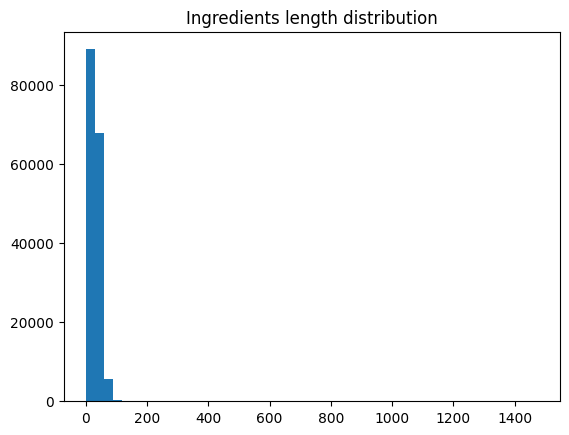

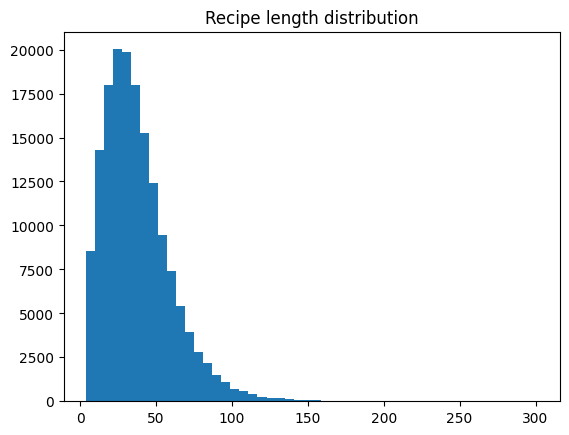

In [10]:
src_lengths = df_train['Ingredients'].apply(lambda x: len(str(x).split()))
tgt_lengths = df_train['Recipe'].apply(lambda x: len(str(x).split()))

plt.hist(src_lengths, bins=50)
plt.title("Ingredients length distribution")
plt.show()

plt.hist(tgt_lengths, bins=50)
plt.title("Recipe length distribution")
plt.show()

In [11]:
from collections import Counter
all_words = " ".join(df_train['Recipe'].astype(str)).split()
counter = Counter(all_words)
print("Top 20 words:", counter.most_common(20))
print("Rare words:", sum(1 for w, c in counter.items() if c == 1))

Top 20 words: [('and', 365343), ('in', 176400), ('to', 129616), ('until', 107095), ('with', 98625), ('a', 93189), ('the', 83462), ('"Add', 81473), ('of', 66829), ('into', 57923), ('for', 55264), ('on', 52803), ('over', 50363), ('or', 49316), ('add', 38722), ('1', 37088), ('all', 31502), ('ingredients', 30829), ('["Mix', 29442), ('2', 28549)]
Rare words: 31392


### Special Token Handling

In [12]:
from nltk.tokenize import word_tokenize

PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN = '<PAD>', '<UNK>', '<SOS>', '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
FREQ_THRESHOLD = 3

def parse_json_list(raw):
    try:
        return json.loads(raw)
    except Exception:
        return []

def tokenize(text):
    return word_tokenize(text.lower())

def load_and_tokenize(path):
    df = pd.read_csv(path)
    src_seqs, tgt_seqs = [], []
    for _, row in df.iterrows():
        ingredients  = parse_json_list(row['Ingredients'])
        recipe_steps = parse_json_list(row['Recipe'])
        src_text = ' , '.join(ingredients)
        tgt_text = ' <STEP> '.join(recipe_steps)
        src_seqs.append(tokenize(src_text))
        tgt_seqs.append(tokenize(tgt_text))
    return src_seqs, tgt_seqs

def build_vocab(src_seqs, tgt_seqs, freq_threshold=FREQ_THRESHOLD):
    counter = Counter()
    for seq in src_seqs + tgt_seqs:
        counter.update(seq)
    word2idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
    for word, freq in counter.items():
        if freq >= freq_threshold and word not in word2idx:
            word2idx[word] = len(word2idx)
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

def tokens_to_ids(tokens, word2idx, add_sos=False, add_eos=True):
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    if add_sos: ids = [SOS_IDX] + ids
    if add_eos: ids = ids + [EOS_IDX]
    return ids

def encode_split(src_seqs, tgt_seqs, word2idx):
    enc_src = [tokens_to_ids(s, word2idx, add_sos=False, add_eos=True) for s in src_seqs]
    enc_tgt = [tokens_to_ids(t, word2idx, add_sos=True,  add_eos=True) for t in tgt_seqs]
    return enc_src, enc_tgt

In [13]:
VOCAB_PATH   = os.path.join(DRIVE_DIR, 'vocab.pkl')
ENCODED_PATH = os.path.join(DRIVE_DIR, 'encoded_data.pkl')
TOK_PATH     = os.path.join(DRIVE_DIR, 'tokenized_data.pkl')

if os.path.exists(ENCODED_PATH) and os.path.exists(VOCAB_PATH):
    with open(VOCAB_PATH, 'rb') as f:
        word2idx, idx2word = pickle.load(f)
    with open(ENCODED_PATH, 'rb') as f:
        train_src_ids, train_tgt_ids, dev_src_ids, \
        dev_tgt_ids, test_src_ids, test_tgt_ids = pickle.load(f)
    with open(TOK_PATH, 'rb') as f:
        train_src_tok, train_tgt_tok, dev_src_tok, \
        dev_tgt_tok, test_src_tok, test_tgt_tok = pickle.load(f)
    VOCAB_SIZE = len(word2idx)
    print(f'Loaded vocab ({VOCAB_SIZE:,}), encoded data, and tokens from Drive.')
else:
    train_src_tok, train_tgt_tok = load_and_tokenize(TRAIN_PATH)
    dev_src_tok,   dev_tgt_tok   = load_and_tokenize(DEV_PATH)
    test_src_tok,  test_tgt_tok  = load_and_tokenize(TEST_PATH)
    word2idx, idx2word = build_vocab(train_src_tok, train_tgt_tok, FREQ_THRESHOLD)
    VOCAB_SIZE = len(word2idx)
    train_src_ids, train_tgt_ids = encode_split(train_src_tok, train_tgt_tok, word2idx)
    dev_src_ids,   dev_tgt_ids   = encode_split(dev_src_tok,   dev_tgt_tok,   word2idx)
    test_src_ids,  test_tgt_ids  = encode_split(test_src_tok,  test_tgt_tok,  word2idx)
    with open(VOCAB_PATH, 'wb') as f: pickle.dump((word2idx, idx2word), f)
    with open(ENCODED_PATH, 'wb') as f:
        pickle.dump((train_src_ids, train_tgt_ids, dev_src_ids,
                     dev_tgt_ids, test_src_ids, test_tgt_ids), f)
    with open(TOK_PATH, 'wb') as f:
        pickle.dump((train_src_tok, train_tgt_tok, dev_src_tok,
                     dev_tgt_tok, test_src_tok, test_tgt_tok), f)
    print('All data saved to Drive.')

def compute_oov_rate(src_seqs, tgt_seqs, word2idx):
    total = oov = 0
    for seq in src_seqs + tgt_seqs:
        for tok in seq:
            total += 1
            if tok not in word2idx: oov += 1
    return oov / total if total > 0 else 0.0

dev_oov = compute_oov_rate(dev_src_tok, dev_tgt_tok, word2idx)
print(f'OOV rate on dev: {dev_oov*100:.2f}%')

Loaded vocab (9,516), encoded data, and tokens from Drive.
OOV rate on dev: 0.12%


In [14]:
MAX_SRC_LEN = 150
MAX_TGT_LEN = 300
BATCH_SIZE  = 32

class RecipeDataset(Dataset):
    def __init__(self, src_ids, tgt_ids, max_src=MAX_SRC_LEN, max_tgt=MAX_TGT_LEN):
        self.src = [s[:max_src] for s in src_ids]
        self.tgt = [t[:max_tgt] for t in tgt_ids]
    def __len__(self): return len(self.src)
    def __getitem__(self, idx):
        return (torch.tensor(self.src[idx], dtype=torch.long),
                torch.tensor(self.tgt[idx], dtype=torch.long))

def collate_fn(batch):
    src_b, tgt_b = zip(*batch)
    return (pad_sequence(src_b, batch_first=True, padding_value=PAD_IDX),
            pad_sequence(tgt_b, batch_first=True, padding_value=PAD_IDX))

train_dataset = RecipeDataset(train_src_ids, train_tgt_ids)
dev_dataset   = RecipeDataset(dev_src_ids,   dev_tgt_ids)
test_dataset  = RecipeDataset(test_src_ids,  test_tgt_ids)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, pin_memory=True, num_workers=2)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, pin_memory=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, pin_memory=True, num_workers=2)

print(f'Train: {len(train_loader):,} batches | Dev: {len(dev_loader):,} | Test: {len(test_loader):,}')

for tok, idx in zip(SPECIAL_TOKENS, [PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX]):
    assert word2idx[tok] == idx
print("✓ Special tokens verified")

Train: 5,091 batches | Dev: 34 | Test: 34
✓ Special tokens verified


In [15]:


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, token, hidden):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.rnn(embedded, hidden)
        return self.fc_out(output.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder; self.decoder = decoder; self.device = device
    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        _, hidden  = self.encoder(src)
        dec_input  = tgt[:, 0]
        outputs    = torch.zeros(B, tgt_len - 1, vocab_size, device=self.device)
        for t in range(1, tgt_len):
            logits, hidden = self.decoder(dec_input, hidden)
            outputs[:, t-1, :] = logits
            dec_input = tgt[:, t] if random.random() < teacher_forcing_ratio \
                        else logits.argmax(dim=-1)
        return outputs

class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden, dec_hidden, attn_dim=256):
        super().__init__()
        self.W1 = nn.Linear(enc_hidden, attn_dim, bias=False)
        self.W2 = nn.Linear(dec_hidden, attn_dim, bias=False)
        self.v  = nn.Linear(attn_dim, 1, bias=False)
    def forward(self, enc_out, dec_hidden):
        energy = self.v(torch.tanh(
            self.W1(enc_out) + self.W2(dec_hidden).unsqueeze(1))).squeeze(2)
        attn_w = F.softmax(energy, dim=1)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out).squeeze(1)
        return context, attn_w

class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dec_hidden, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hidden, dec_hidden)
        self.rnn    = nn.GRU(emb_dim + enc_hidden, dec_hidden, num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, token, hidden, enc_out):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        context, attn_w = self.attention(enc_out, hidden[-1])
        rnn_in  = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, hidden = self.rnn(rnn_in, hidden)
        return self.fc_out(output.squeeze(1)), hidden, attn_w

class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder; self.decoder = decoder; self.device = device
    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        enc_out, hidden = self.encoder(src)
        dec_input = tgt[:, 0]
        outputs   = torch.zeros(B, tgt_len - 1, vocab_size, device=self.device)
        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(dec_input, hidden, enc_out)
            outputs[:, t-1, :] = logits
            dec_input = tgt[:, t] if random.random() < teacher_forcing_ratio \
                        else logits.argmax(dim=-1)
        return outputs

def build_baseline_model():
    enc = Encoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    dec = Decoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
    print(f'Baseline params: {sum(p.numel() for p in model.parameters()):,}')
    return model

def build_attn_model():
    enc = Encoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    dec = AttnDecoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    model = Seq2SeqAttn(enc, dec, DEVICE).to(DEVICE)
    print(f'Attention params: {sum(p.numel() for p in model.parameters()):,}')
    return model

In [16]:
def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    total_loss = n_tokens = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output   = model(src, tgt, tf_ratio)
        out_flat = output.reshape(-1, output.shape[-1])
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss     = criterion(out_flat, tgt_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        mask = tgt_flat != PAD_IDX
        total_loss += loss.item() * mask.sum().item()
        n_tokens   += mask.sum().item()
    return total_loss / n_tokens if n_tokens > 0 else float('inf')

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = n_tokens = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output   = model(src, tgt, teacher_forcing_ratio=0.0)
        out_flat = output.reshape(-1, output.shape[-1])
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss     = criterion(out_flat, tgt_flat)
        mask = tgt_flat != PAD_IDX
        total_loss += loss.item() * mask.sum().item()
        n_tokens   += mask.sum().item()
    return total_loss / n_tokens if n_tokens > 0 else float('inf')

def train_model(model, train_loader, dev_loader, n_epochs, lr, clip,
                tf_ratio, patience, ckpt_path):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    state_path = ckpt_path.replace('.pt', '_state.pkl')
    train_losses, dev_losses = [], []
    best_dev, no_improve, start_epoch = float('inf'), 0, 1

    if os.path.exists(state_path):
        with open(state_path, 'rb') as f:
            state = pickle.load(f)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        train_losses = state['train_losses']
        dev_losses   = state['dev_losses']
        best_dev     = state['best_dev']
        no_improve   = state['no_improve']
        start_epoch  = state['epoch'] + 1
        print(f'Resumed from epoch {start_epoch-1}, best dev = {best_dev:.4f}')

    for epoch in range(start_epoch, n_epochs + 1):
        t0      = time.time()
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, clip, tf_ratio)
        dv_loss = evaluate(model, dev_loader, criterion)
        old_lr  = optimizer.param_groups[0]['lr']
        scheduler.step(dv_loss)
        new_lr  = optimizer.param_groups[0]['lr']
        train_losses.append(tr_loss); dev_losses.append(dv_loss)
        lr_tag = f' | LR→{new_lr:.2e}' if new_lr != old_lr else ''
        print(f'Epoch {epoch:02d}/{n_epochs} | Train: {tr_loss:.4f} | '
              f'Dev: {dv_loss:.4f} | {time.time()-t0:.1f}s{lr_tag}')
        if dv_loss < best_dev:
            best_dev = dv_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ✓ Best dev {best_dev:.4f} — saved')
        else:
            no_improve += 1
            print(f'  No improvement ({no_improve}/{patience})')
            if no_improve >= patience:
                print('Early stopping.'); break
        with open(state_path, 'wb') as f:
            pickle.dump({'epoch': epoch, 'train_losses': train_losses,
                         'dev_losses': dev_losses, 'best_dev': best_dev,
                         'no_improve': no_improve, 'optimizer': optimizer.state_dict(),
                         'scheduler': scheduler.state_dict()}, f)
    return train_losses, dev_losses

def plot_loss_curves(train_losses, dev_losses, title='Loss Curves'):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = range(1, len(train_losses) + 1)
    ax.plot(ep, train_losses, 'o-', label='Train', color='steelblue')
    ax.plot(ep, dev_losses,   's-', label='Dev',   color='tomato')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Token CE Loss')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

In [17]:
EMB_DIM    = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.3
LEARNING_RATE         = 1e-4
TEACHER_FORCING_RATIO = 0.5
CLIP       = 1.0
PATIENCE   = 5
BATCH_SIZE = 64


=== Teacher Forcing Ratio: 0.3 ===
  Epoch 1 | Train: 7.7789 | Dev: 5.7775
  Epoch 2 | Train: 5.3632 | Dev: 5.2382
  Epoch 3 | Train: 5.1960 | Dev: 5.2062
  Epoch 4 | Train: 5.1698 | Dev: 5.1922

=== Teacher Forcing Ratio: 0.5 ===
  Epoch 1 | Train: 7.9159 | Dev: 5.8062
  Epoch 2 | Train: 5.3680 | Dev: 5.2375
  Epoch 3 | Train: 5.1960 | Dev: 5.2064
  Epoch 4 | Train: 5.1600 | Dev: 5.1950

=== Teacher Forcing Ratio: 0.7 ===
  Epoch 1 | Train: 7.7756 | Dev: 5.7633
  Epoch 2 | Train: 5.3519 | Dev: 5.2389
  Epoch 3 | Train: 5.1876 | Dev: 5.2094
  Epoch 4 | Train: 5.0708 | Dev: 5.3126

=== Teacher Forcing Ablation Summary ===
TF Ratio     Best Dev Loss   Final Train Loss
---------------------------------------------
0.3          5.1922          5.1698
0.5          5.1950          5.1600
0.7          5.2094          5.0708

→ Best TF ratio: 0.3


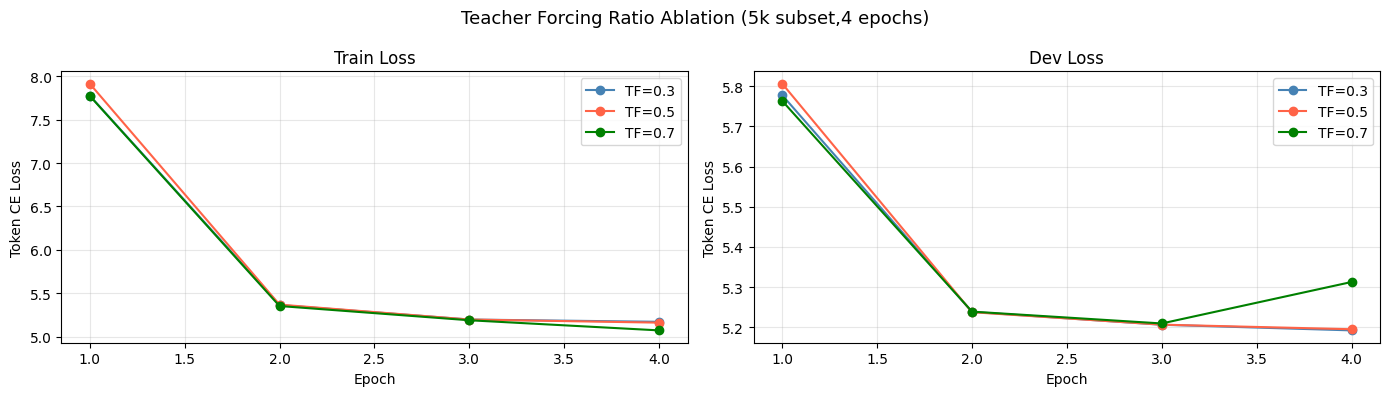

In [18]:
# ── Teacher Forcing Ratio Ablation ──────────────────────────────────────────
ABLATION_SIZE = 5000
ablation_src  = train_src_ids[:ABLATION_SIZE]
ablation_tgt  = train_tgt_ids[:ABLATION_SIZE]
ablation_dataset = RecipeDataset(ablation_src, ablation_tgt)
ablation_loader  = DataLoader(ablation_dataset, batch_size=BATCH_SIZE,
                               shuffle=True, collate_fn=collate_fn,
                               pin_memory=True, num_workers=2)

TF_RATIOS           = [0.3, 0.5, 0.7]
tf_ablation_results = {}

for tf_ratio in TF_RATIOS:
    print(f'\n=== Teacher Forcing Ratio: {tf_ratio} ===')
    gc.collect(); torch.cuda.empty_cache()

    # Fresh model — no checkpoint resume
    enc   = Encoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    dec   = Decoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    tr_losses, dv_losses = [], []

    for epoch in range(1, 5):
        tr = train_epoch(model, ablation_loader, optimizer, criterion, CLIP, tf_ratio)
        dv = evaluate(model, dev_loader, criterion)
        tr_losses.append(tr); dv_losses.append(dv)
        print(f'  Epoch {epoch} | Train: {tr:.4f} | Dev: {dv:.4f}')

    tf_ablation_results[tf_ratio] = {
        'train_losses': tr_losses,
        'dev_losses'  : dv_losses,
        'best_dev'    : min(dv_losses)
    }

# Summary table
print('\n=== Teacher Forcing Ablation Summary ===')
print(f'{"TF Ratio":<12} {"Best Dev Loss":<15} {"Final Train Loss"}')
print('-' * 45)
for tf, res in tf_ablation_results.items():
    print(f'{tf:<12} {res["best_dev"]:<15.4f} {res["train_losses"][-1]:.4f}')

best_tf = min(tf_ablation_results, key=lambda k: tf_ablation_results[k]['best_dev'])
print(f'\n→ Best TF ratio: {best_tf}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['steelblue', 'tomato', 'green']

for ax, metric, title in [(axes[0], 'train_losses', 'Train Loss'),
                           (axes[1], 'dev_losses',   'Dev Loss')]:
    for (tf, res), color in zip(tf_ablation_results.items(), colors):
        ax.plot(range(1, len(res[metric]) + 1), res[metric], 'o-', label=f'TF={tf}', color=color)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel('Token CE Loss'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Teacher Forcing Ratio Ablation (5k subset,4 epochs)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'tf_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


=== LEARNING_RATE: 0.0001 ===
  Params: 6,264,108
  Epoch 1 | Train: 7.8470 | Dev: 5.7718
  Epoch 2 | Train: 5.3495 | Dev: 5.2356
  Epoch 3 | Train: 5.1963 | Dev: 5.2063
  Epoch 4 | Train: 5.1695 | Dev: 5.1918

=== LEARNING_RATE: 0.001 ===
  Params: 6,264,108
  Epoch 1 | Train: 5.5693 | Dev: 5.2170
  Epoch 2 | Train: 4.9171 | Dev: 5.3406
  Epoch 3 | Train: 4.7354 | Dev: 5.5176
  Epoch 4 | Train: 4.6433 | Dev: 5.5741

=== LEARNING_RATE: 0.005 ===
  Params: 6,264,108
  Epoch 1 | Train: 5.0734 | Dev: 5.7944
  Epoch 2 | Train: 4.5435 | Dev: 5.7503
  Epoch 3 | Train: 4.3291 | Dev: 5.9096
  Epoch 4 | Train: 4.2195 | Dev: 5.7768

=== Learning Rate Ablation Summary ===
Value              Params Best Dev Loss    Final Train Loss
--------------------------------------------------------
0.0001          6,264,108 5.1918           5.1695
0.001           6,264,108 5.2170           4.6433
0.005           6,264,108 5.7503           4.2195

→ Best Learning Rate: 0.0001


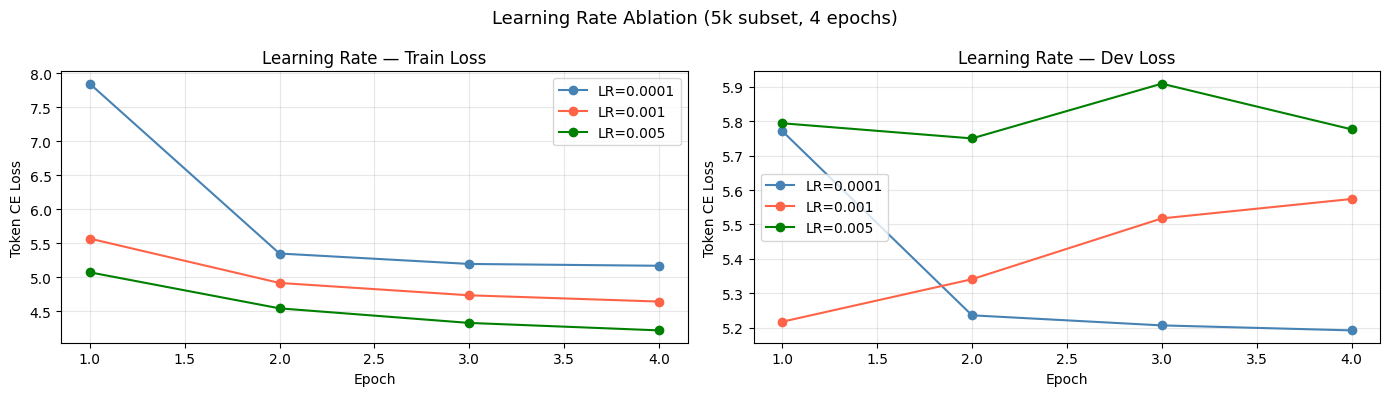

In [19]:
# ── LR Ablation ────────────────────────────────────────────────────────────────
LR_CANDIDATES = [1e-4, 1e-3, 5e-3]

ABLATION_SIZE = 5000
ablation_src     = train_src_ids[:ABLATION_SIZE]
ablation_tgt     = train_tgt_ids[:ABLATION_SIZE]
ablation_dataset = RecipeDataset(ablation_src, ablation_tgt)
ablation_loader  = DataLoader(ablation_dataset, batch_size=BATCH_SIZE,
                               shuffle=True, collate_fn=collate_fn,
                               pin_memory=True, num_workers=2)

# ── Learning Rate Ablation (dropout fixed at baseline 0.3) ────────────────────
lr_ablation_results = {}
for lr in LR_CANDIDATES:
    print(f'\n=== LEARNING_RATE: {lr} ===')
    gc.collect(); torch.cuda.empty_cache()

    enc   = Encoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    dec   = Decoder(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
    print(f'  Params: {sum(p.numel() for p in model.parameters()):,}')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    tr_losses, dv_losses = [], []
    for epoch in range(1, 5):
        tr = train_epoch(model, ablation_loader, optimizer, criterion, CLIP,
                         TEACHER_FORCING_RATIO)
        dv = evaluate(model, dev_loader, criterion)
        tr_losses.append(tr); dv_losses.append(dv)
        print(f'  Epoch {epoch} | Train: {tr:.4f} | Dev: {dv:.4f}')

    lr_ablation_results[lr] = {
        'train_losses': tr_losses,
        'dev_losses'  : dv_losses,
        'best_dev'    : min(dv_losses),
        'params'      : sum(p.numel() for p in model.parameters()),
    }

# ── Summary Table ──────────────────────────────────────────────────────────────
print('\n=== Learning Rate Ablation Summary ===')
print(f'{"Value":<12} {"Params":>12} {"Best Dev Loss":<16} {"Final Train Loss"}')
print('-' * 56)
for val, res in lr_ablation_results.items():
    print(f'{val:<12} {res["params"]:>12,} {res["best_dev"]:<16.4f} {res["train_losses"][-1]:.4f}')
best = min(lr_ablation_results, key=lambda k: lr_ablation_results[k]['best_dev'])
print(f'\n→ Best Learning Rate: {best}')

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['steelblue', 'tomato', 'green']

for col, (metric, title) in enumerate([('train_losses', 'Train Loss'),
                                        ('dev_losses',   'Dev Loss')]):
    ax = axes[col]
    for (val, res), color in zip(lr_ablation_results.items(), colors):
        ax.plot(range(1, 5), res[metric], 'o-', label=f'LR={val}', color=color)
    ax.set_title(f'Learning Rate — {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Token CE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Learning Rate Ablation (5k subset, 4 epochs)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'lr_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
EMB_DIM    = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.3
LEARNING_RATE         = 1e-4
TEACHER_FORCING_RATIO = 0.5
CLIP       = 1.0
PATIENCE   = 3
BATCH_SIZE = 64

In [21]:
BASELINE_CKPT = os.path.join(DRIVE_DIR, f'baseline_lr{LEARNING_RATE}_fresh.pt')

gc.collect(); torch.cuda.empty_cache()
baseline_model = build_baseline_model()
baseline_train_losses, baseline_dev_losses = train_model(
    baseline_model, train_loader, dev_loader,
    n_epochs=10,
    lr=LEARNING_RATE,
    clip=CLIP,
    tf_ratio=TEACHER_FORCING_RATIO,
    patience=PATIENCE,
    ckpt_path=BASELINE_CKPT
)

Baseline params: 6,264,108
Resumed from epoch 3, best dev = 5.5477
Epoch 04/10 | Train: 4.0465 | Dev: 5.6567 | 1260.9s | LR→5.00e-05
  No improvement (3/3)
Early stopping.


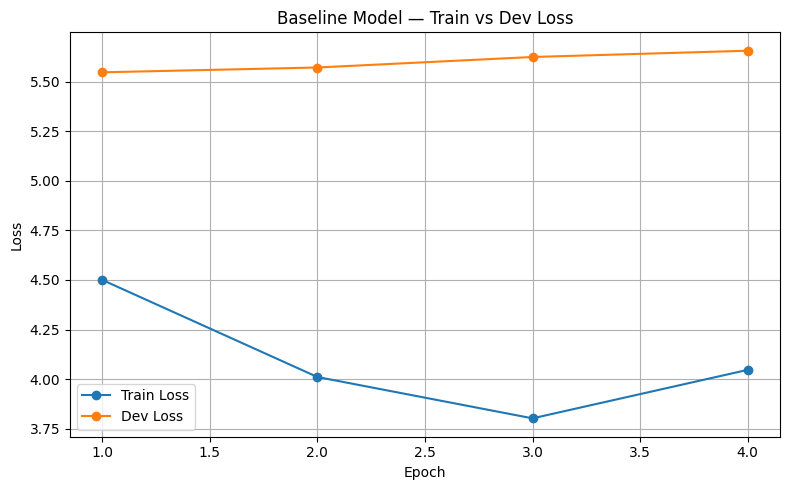

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(baseline_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_train_losses, label='Train Loss', marker='o')
plt.plot(epochs, baseline_dev_losses, label='Dev Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model — Train vs Dev Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
import os

ATTN_CKPT = os.path.join(DRIVE_DIR, 'attn_model.pt')  # saves to Drive, not local disk

gc.collect(); torch.cuda.empty_cache()
attn_model = build_attn_model()
attn_train_losses, attn_dev_losses = train_model(
    attn_model, train_loader, dev_loader,
    n_epochs=10,
    lr=LEARNING_RATE,
    clip=CLIP,
    tf_ratio=TEACHER_FORCING_RATIO,
    patience=PATIENCE,
    ckpt_path=ATTN_CKPT
)

Attention params: 6,592,044
Resumed from epoch 3, best dev = 5.5601
Epoch 04/10 | Train: 3.6758 | Dev: 5.6058 | 2044.6s
  No improvement (1/3)
Epoch 05/10 | Train: 3.5936 | Dev: 5.6073 | 2058.9s
  No improvement (2/3)
Epoch 06/10 | Train: 3.5355 | Dev: 5.6089 | 2059.0s | LR→5.00e-05
  No improvement (3/3)
Early stopping.


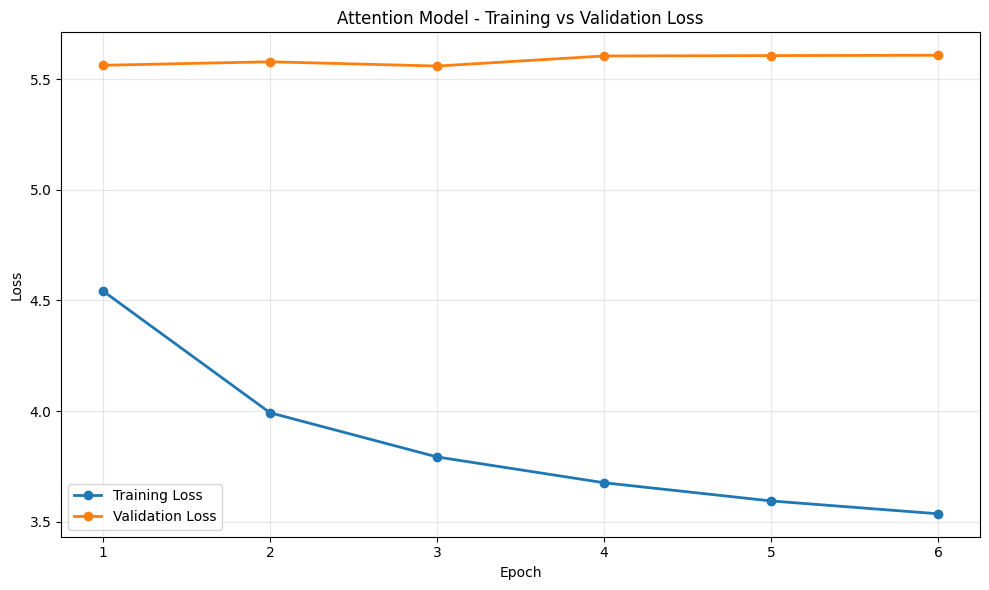

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(attn_train_losses, label='Training Loss', marker='o', linewidth=2)
plt.plot(attn_dev_losses, label='Validation Loss', marker='o', linewidth=2)

plt.title('Attention Model - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(len(attn_train_losses)), range(1, len(attn_train_losses) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('attn_loss_curve.png', dpi=150)
plt.show()

In [32]:
@torch.no_grad()
def greedy_decode_baseline(model, src_tensor, max_len=MAX_TGT_LEN):
    model.eval()
    if src_tensor.dim() == 1: src_tensor = src_tensor.unsqueeze(0)
    src_tensor = src_tensor.to(DEVICE)
    _, hidden  = model.encoder(src_tensor)
    dec_input  = torch.tensor([SOS_IDX], device=DEVICE)
    generated  = []
    for _ in range(max_len):
        logits, hidden = model.decoder(dec_input, hidden)
        pred = logits.argmax(dim=-1)
        if pred.item() == EOS_IDX: break
        generated.append(pred.item())
        dec_input = pred
    return generated

@torch.no_grad()
def greedy_decode_attn(model, src_tensor, max_len=MAX_TGT_LEN):
    model.eval()
    if src_tensor.dim() == 1: src_tensor = src_tensor.unsqueeze(0)
    src_tensor = src_tensor.to(DEVICE)
    enc_out, hidden = model.encoder(src_tensor)
    dec_input  = torch.tensor([SOS_IDX], device=DEVICE)
    generated, attn_rows = [], []
    for _ in range(max_len):
        logits, hidden, attn_w = model.decoder(dec_input, hidden, enc_out)
        attn_rows.append(attn_w.squeeze(0).cpu().numpy())
        pred = logits.argmax(dim=-1)
        if pred.item() == EOS_IDX: break
        generated.append(pred.item())
        dec_input = pred
    return generated, np.array(attn_rows)

def ids_to_tokens(ids, idx2word, remove_step=True, remove_unk=True):
    skip = {PAD_IDX, SOS_IDX, EOS_IDX}
    tokens = [idx2word.get(i, UNK_TOKEN) for i in ids if i not in skip]
    if remove_step:
        tokens = [t for t in tokens if t != '<step>']
    if remove_unk:
        tokens = [t for t in tokens if t != UNK_TOKEN]
    # Join and clean up leftover step markers
    text = ' '.join(tokens)
    text = text.replace('< step >', '').replace('<step>', '')
    tokens = text.split()
    return tokens

# ── Exact copy of evaluate1 from eval_metrics.py ─────────────────────────────
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as meteor_score_fn
from bert_score import score as bert_score

def compute_metrics(hyps, refs, split_name='test'):
    # Convert token lists → strings (evaluate1 expects plain strings)
    gold_recipes = [' '.join(r) for r in refs]
    pred_recipes = [' '.join(h) for h in hyps]

    bleu4, meteor = [], []
    for gold, pred in zip(gold_recipes, pred_recipes):
        ref = nltk.word_tokenize(gold)
        hyp = nltk.word_tokenize(pred)
        sm  = SmoothingFunction().method4
        bleu4.append(sentence_bleu([ref], hyp, weights=(.25,.25,.25,.25),
                                   smoothing_function=sm))
        meteor.append(meteor_score_fn([ref], hyp))

    _, _, F1 = bert_score(pred_recipes, gold_recipes, lang='en', verbose=False)

    print(f'\n=== {split_name} ===')
    print(f'  BLEU-4    : {np.mean(bleu4):.4f}')
    print(f'  METEOR    : {np.mean(meteor):.4f}')
    print(f'  BERTScore : {F1.numpy().mean():.4f}')
    return {
        'bleu4'  : float(np.mean(bleu4)),
        'meteor' : float(np.mean(meteor)),
        'bert_f1': float(F1.numpy().mean())
    }

In [33]:
# Load best checkpoints
baseline_model.load_state_dict(torch.load(BASELINE_CKPT, map_location=DEVICE))
attn_model.load_state_dict(torch.load(ATTN_CKPT, map_location=DEVICE))

print('Generating baseline predictions...')
baseline_hyps, baseline_refs = [], []
for i in range(len(test_dataset)):
    src, tgt = test_dataset[i]
    baseline_hyps.append(ids_to_tokens(greedy_decode_baseline(baseline_model, src), idx2word))
    baseline_refs.append(ids_to_tokens(tgt.tolist(), idx2word))

print('Generating attention predictions...')
attn_hyps, attn_refs = [], []
for i in range(len(test_dataset)):
    src, tgt = test_dataset[i]
    pred_ids, _ = greedy_decode_attn(attn_model, src)
    attn_hyps.append(ids_to_tokens(pred_ids, idx2word))
    attn_refs.append(ids_to_tokens(tgt.tolist(), idx2word))

print(f'Done — {len(baseline_hyps)} examples generated.')

baseline_metrics = compute_metrics(baseline_hyps, baseline_refs, 'Baseline (Test)')
attn_metrics     = compute_metrics(attn_hyps,     attn_refs,     'Attention (Test)')

Generating baseline predictions...
Generating attention predictions...
Done — 1081 examples generated.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Baseline (Test) ===
  BLEU-4    : 0.0059
  METEOR    : 0.0973
  BERTScore : 0.7520


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Attention (Test) ===
  BLEU-4    : 0.0258
  METEOR    : 0.1697
  BERTScore : 0.8190


Source (22 tokens): 1 ( 8 oz . ) pkg . cream cheese , 1 small jar marshmallow creme , 1 tbsp . ...
Prediction (25 tokens): mix cream cheese and cream cheese . add in cream cheese and add in cream cheese . chill until firm . serve with crackers . ...


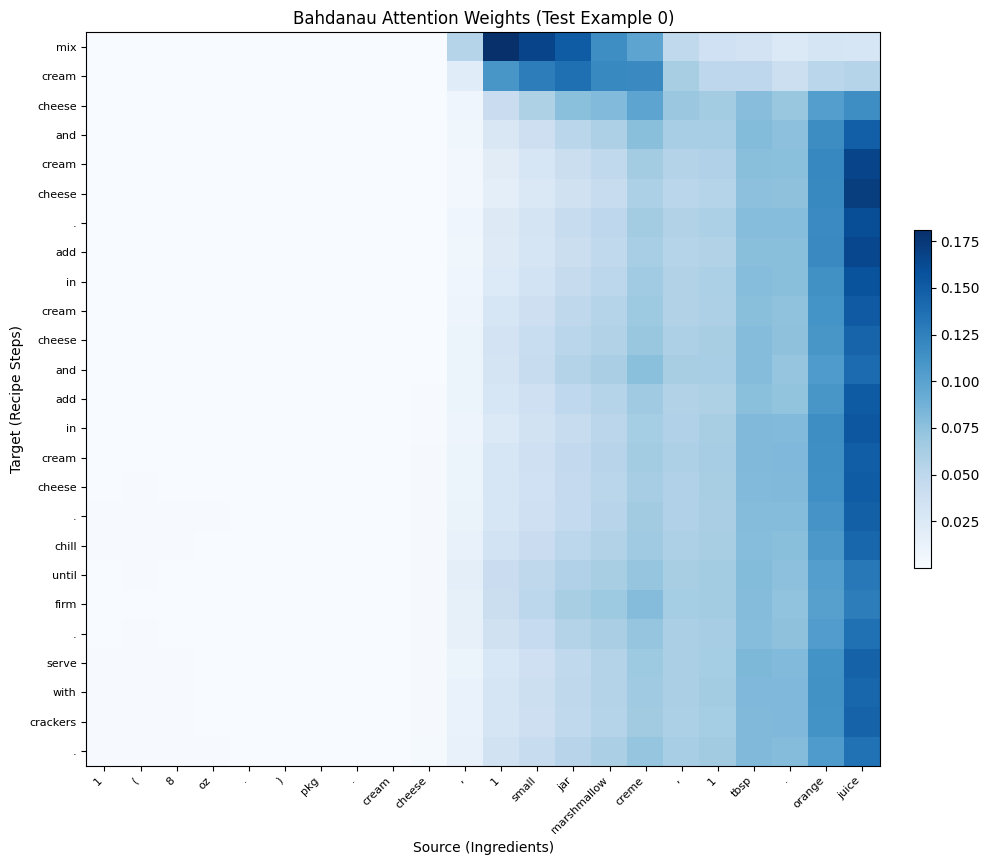

In [34]:
def plot_attention_heatmap(src_tokens, tgt_tokens, attn_matrix, title='Attention Weights'):
    max_s = min(len(src_tokens), 30)
    max_t = min(len(tgt_tokens), 30)
    disp  = attn_matrix[:max_t, :max_s]
    fig, ax = plt.subplots(figsize=(max(10, max_s*0.4), max(6, max_t*0.35)))
    im = ax.imshow(disp, cmap='Blues', aspect='auto')
    ax.set_xticks(range(max_s))
    ax.set_xticklabels(src_tokens[:max_s], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(max_t))
    ax.set_yticklabels(tgt_tokens[:max_t], fontsize=8)
    ax.set_xlabel('Source (Ingredients)')
    ax.set_ylabel('Target (Recipe Steps)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_DIR, 'attention_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

src_v, tgt_v   = test_dataset[0]
pred_v, attn_v = greedy_decode_attn(attn_model, src_v)
src_tok_v      = ids_to_tokens(src_v.tolist(), idx2word)
pred_tok_v     = ids_to_tokens(pred_v, idx2word)
print(f'Source ({len(src_tok_v)} tokens): {" ".join(src_tok_v[:20])} ...')
print(f'Prediction ({len(pred_tok_v)} tokens): {" ".join(pred_tok_v[:30])} ...')
plot_attention_heatmap(src_tok_v, pred_tok_v, attn_v,
                       title='Bahdanau Attention Weights (Test Example 0)')

In [35]:
results = pd.DataFrame({
    'Model'    : ['Baseline RNN (no attn)', 'RNN + Bahdanau Attn'],
    'BLEU-4'   : [round(baseline_metrics['bleu4'],   4), round(attn_metrics['bleu4'],   4)],
    'METEOR'   : [round(baseline_metrics['meteor'],  4), round(attn_metrics['meteor'],  4)],
    'BERTScore': [round(baseline_metrics['bert_f1'], 4), round(attn_metrics['bert_f1'], 4)],
})
print(results.to_string(index=False))
results.to_csv(os.path.join(DRIVE_DIR, 'task1_results.csv'), index=False)
print('\nResults saved to Google Drive.')

                 Model  BLEU-4  METEOR  BERTScore
Baseline RNN (no attn)  0.0059  0.0973      0.752
   RNN + Bahdanau Attn  0.0258  0.1697      0.819

Results saved to Google Drive.


In [36]:
print('=== Qualitative Comparison (3 Test Examples) ===')
for i in range(3):
    src_t = ids_to_tokens(test_src_ids[i], idx2word)
    print(f'\n==== Example {i+1} ====')
    print(f'Ingredients : {" ".join(src_t[:25])}')
    print(f'Reference   : {" ".join(attn_refs[i][:60])}')
    print(f'Baseline    : {" ".join(baseline_hyps[i][:60])}')
    print(f'Attention   : {" ".join(attn_hyps[i][:60])}')

=== Qualitative Comparison (3 Test Examples) ===

==== Example 1 ====
Ingredients : 1 ( 8 oz . ) pkg . cream cheese , 1 small jar marshmallow creme , 1 tbsp . orange juice
Reference   : whip cream cheese with mixer until smooth . blend in orange juice . add marshmallow creme . whip again until smooth . chill before serving .
Baseline    : mix all ingredients in . add in and . add in and . add in and . add in and . add in and . add in and . add in and . add in and . add in and . add in and . add in and . add in . add in . add in . add in
Attention   : mix cream cheese and cream cheese . add in cream cheese and add in cream cheese . chill until firm . serve with crackers .

==== Example 2 ====
Ingredients : 1 lb . ground beef , 1/2 c. onions , cut up ( sauteed in butter or oil ) , 1 tsp . mustard ,
Reference   : combine all ingredients . cook 30 minutes . serve on warm buns .
Baseline    : mix all ingredients in . add in and . add in and . add in and . add in and . add in and . add in an

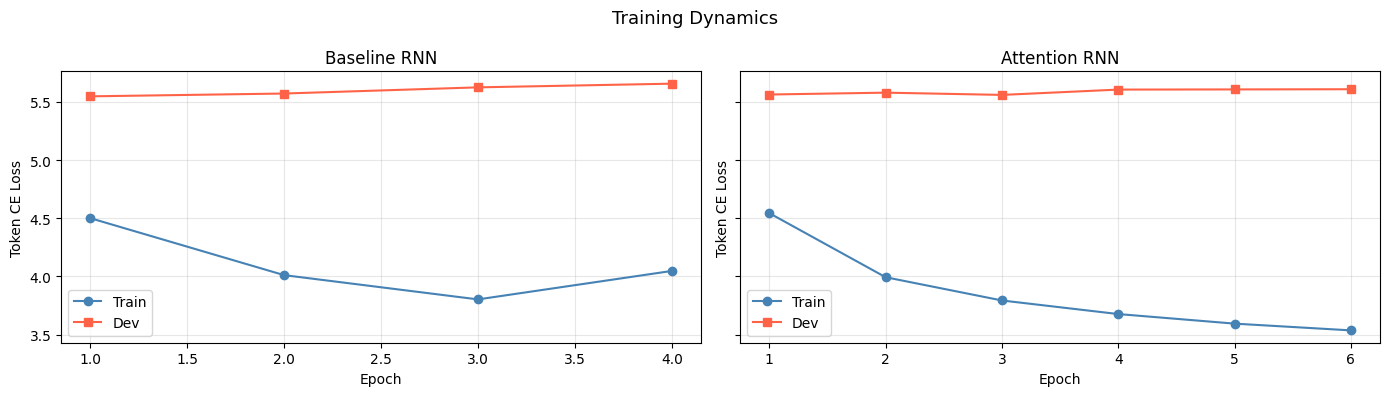

Baseline — 4 epochs, best dev at epoch 1
Attention — 6 epochs, best dev at epoch 3


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, tr, dv, title in [
        (axes[0], baseline_train_losses, baseline_dev_losses, 'Baseline RNN'),
        (axes[1], attn_train_losses,     attn_dev_losses,     'Attention RNN')]:
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, 'o-', label='Train', color='steelblue')
    ax.plot(ep, dv, 's-', label='Dev',   color='tomato')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel('Token CE Loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Training Dynamics', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'loss_curves_combined.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Baseline — {len(baseline_train_losses)} epochs, '
      f'best dev at epoch {int(np.argmin(baseline_dev_losses))+1}')
print(f'Attention — {len(attn_train_losses)} epochs, '
      f'best dev at epoch {int(np.argmin(attn_dev_losses))+1}')

In [38]:
import pickle

# Save after generating baseline_hyps and attn_hyps
with open(os.path.join(DRIVE_DIR, 't1_predictions.pkl'), 'wb') as f:
    pickle.dump({
        'baseline_hyps': baseline_hyps,
        'attn_hyps'    : attn_hyps,
        'refs'         : baseline_refs,  # gold references
    }, f)
print('T1 predictions saved.')

T1 predictions saved.
